In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [3]:
df_2 = pd.read_csv("insurance.csv")
df_2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
from preprocess import chk_types
chk_types(df_2)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,object,float64,int64,object,object,float64
Num_Uniques,47,2,548,6,2,4,1337


In [6]:
cat_cols = ["sex","children","region","smoker"]
df_2[cat_cols] = df_2[cat_cols].astype("category")

In [7]:
chk_types(df_2)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,category,category,category,float64
Num_Uniques,47,2,548,6,2,4,1337


In [8]:
from preprocess import chk_null
chk_null(df_2)

,age,sex,bmi,children,smoker,region,charges
Null Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Null %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


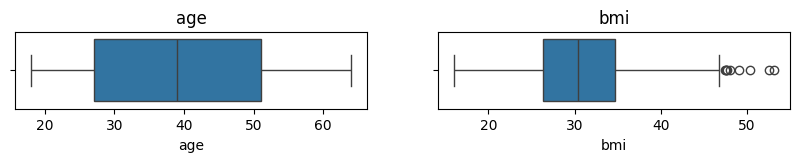

In [9]:
num_cols = ["age","bmi"]
plt.figure(figsize=(10,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.title(f"{col}")
    sns.boxplot(df_2[col],orient="h")
    
plt.show()


In [10]:
Q1 = df_2.bmi.quantile(0.25)
Q3 = df_2.bmi.quantile(0.75)
IQR = Q3 - Q1
Upper = Q3 + 1.5*IQR
outliers = df_2[df_2.bmi > Upper].bmi.values
df_2.bmi.replace(outliers , Upper , inplace=True)

C:\Users\aldawliahasbat\AppData\Local\Temp\ipykernel_38580\456754400.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_2.bmi.replace(outliers , Upper , inplace=True)


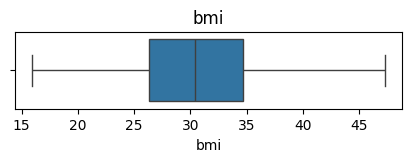

In [ ]:
plt.figure(figsize=(5,1))
plt.title("bmi")
sns.boxplot(df_2.bmi , orient="h")
plt.show()


In [14]:
num_cols = ["age","bmi"]
cat_cols = ["sex","children","region","smoker"]


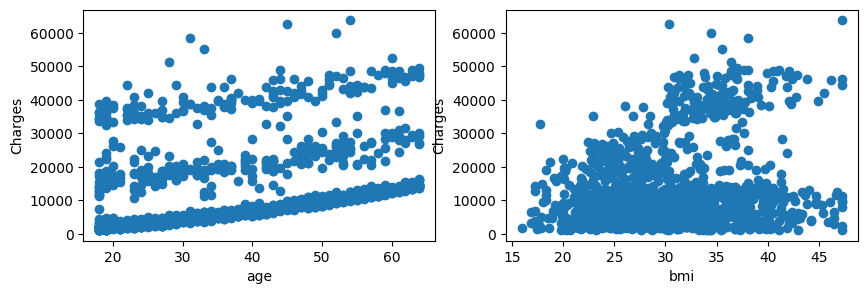

In [16]:
plt.figure(figsize=(10,3))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.xlabel(f"{col}")
    plt.ylabel(f"Charges")
    plt.scatter(df_2[col],df_2.charges)
plt.show()

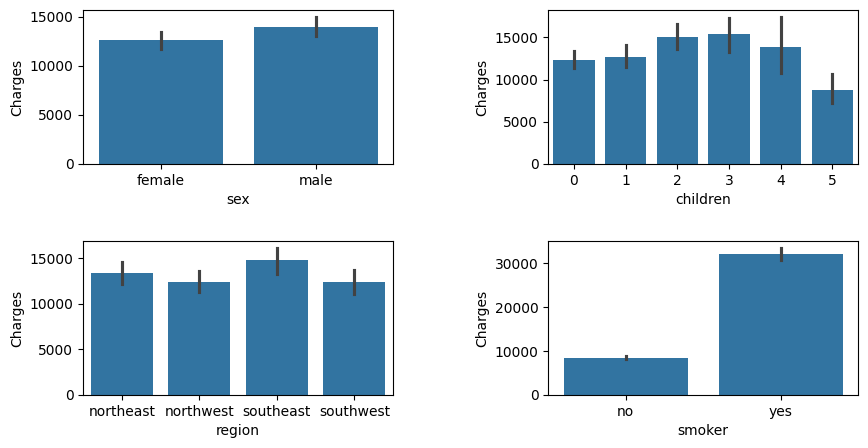

In [24]:
plt.figure(figsize=(10,5))
for i , col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    plt.xlabel(f"{col}")
    plt.ylabel(f"Charges")
    sns.barplot(x = col , y ="charges", data=df_2)
plt.subplots_adjust(hspace=.5 , wspace=.5)
plt.show()

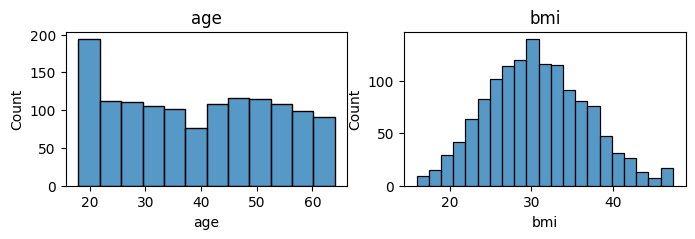

In [25]:
plt.figure(figsize=(8,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.title(f"{col}")
    sns.histplot(x = col , data=df_2)
plt.show()


In [29]:
df_2.duplicated().sum()

np.int64(0)

In [27]:
df_2.drop_duplicates(keep="first",inplace=True)

In [33]:
x = df_2.iloc[:,:-1]
y = df_2.iloc[:,-1:]

In [36]:
from sklearn.preprocessing import MinMaxScaler
cols_to_norm = x.select_dtypes("number").columns
scaler = MinMaxScaler()

In [37]:
x[cols_to_norm] = scaler.fit_transform(x[cols_to_norm])

In [38]:
from category_encoders import OrdinalEncoder
cols_to_encode = ['sex', 'smoker']
ordinal_encoder = OrdinalEncoder(cols=cols_to_encode)
x = ordinal_encoder.fit_transform(x)

In [39]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols=["region"])
x = encoder.fit_transform(x)

In [40]:
x

,age,sex,bmi,children,smoker,region_1,region_2,region_3,region_4
0,0.021739,1,0.381104,0,1,1,0,0,0
1,0.000000,2,0.568465,1,2,0,1,0,0
2,0.217391,2,0.543888,3,2,0,1,0,0
3,0.326087,2,0.215289,0,2,0,0,1,0
4,0.304348,2,0.412384,0,2,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,0.695652,2,0.479094,3,2,0,0,1,0
1334,0.000000,1,0.509416,0,2,0,0,0,1
1335,0.000000,1,0.666773,0,2,0,1,0,0
1336,0.065217,1,0.314076,0,2,1,0,0,0
